# Próg decyzyjny (threshold tuning)

**Regulacja progu decyzyjnego** (ang. **threshold tuning**) to technika, która polega na zmianie domyślnego progu, powyżej którego klasyfikator przypisuje obserwację do klasy pozytywnej, np. fraud, readmisja, choroba. 

W klasyfikacji binarnej domyślny próg często wynosi `0.5`, ale nie zawsze jest on optymalny z punktu widzenia celu analizy. Obniżenie progu zwiększa zwykle czułość modelu, czyli pozwala wykryć więcej przypadków pozytywnych, ale jednocześnie może zwiększyć liczbę fałszywych alarmów. Podwyższenie progu zwykle zwiększa precyzję predykcji pozytywnych, ale może prowadzić do pominięcia większej liczby rzeczywistych przypadków pozytywnych. 

Regulacja progu nie zmienia samego modelu ani przewidywanych prawdopodobieństw, lecz zmienia sposób zamiany tych prawdopodobieństw na końcową decyzję klasyfikacyjną.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score, make_scorer,
    classification_report, confusion_matrix
)

**Dane - Germin Credit Data** (do wyboru)

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
data = fetch_openml("credit-g", version=1, as_frame=True)
X = data.data.select_dtypes(include='number')  # tylko cechy liczbowe dla ułatwienia
y = data.target
dataset = "credit-g"
class_names = y.unique().tolist()
print(class_names)
y = y.map({'good': 0, 'bad': 1}) # mapowanie ułatwiające dalsze analizy

['good', 'bad']


**Dane - Breast cancer** (do wyboru)

In [4]:
data = load_breast_cancer()
X = data.data
y = data.target
dataset = "breast_cancer"

**Podział i skalowanie**:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model bazowy** (regresja logistyczna):

In [6]:
base_model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
base_model.fit(X_train, y_train)

# predict_proba(X_test) zwraca prawdopodobieństwa przynależności do obu klas dla każdego przykładu z zestawu testowego X_test.
# [:, 1] wybiera prawdopodobieństwo klasy pozytywnej (np. klasa 1).
y_probs_base = base_model.predict_proba(X_test)[:, 1]

# Jeśli prawdopodobieństwo ≥ 0.5, przypisuje klasę 1; w przeciwnym razie – 0.
# astype(int) konwertuje wartości logiczne na liczby całkowite (True → 1, False → 0).
y_pred_default = (y_probs_base >= 0.5).astype(int)

**Model z doborem progu**. 

Strojenie progu klasyfikacji (threshold tuning) dla regresji logistycznej, aby zmaksymalizować miarę F1-score:
* Tworzymy klasyfikator regresji logistycznej z automatycznym doborem progu.
* Dobieramy próg tak, aby zoptymalizować F1-score, zamiast używać domyślnego 0.5.
* Klasyfikujemy dane testowe według najlepszego znalezionego progu.

*Jeśli nie wskażemy zmiennej cv, to domyślnie jest k-Fold ustawiona nn 5.*

In [7]:
scorer = make_scorer(f1_score, pos_label=1)
tuned_model = TunedThresholdClassifierCV(estimator=base_model, scoring=scorer)
tuned_model.fit(X_train, y_train)

# j.w.
y_probs_tuned = tuned_model.predict_proba(X_test)[:, 1]
best_threshold = tuned_model.best_threshold_
y_pred_tuned = (y_probs_tuned >= best_threshold).astype(int)

**Wyniki: domyślny próg**:

In [8]:
print("=== Wyniki dla domyślnego progu (0.5) ===")
print(f"F1-score: {f1_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_default):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_default, digits=4))

=== Wyniki dla domyślnego progu (0.5) ===
F1-score: 0.9645
Precision: 0.9855
Recall: 0.9444

Classification report:
              precision    recall  f1-score   support

           0     0.9111    0.9762    0.9425        42
           1     0.9855    0.9444    0.9645        72

    accuracy                         0.9561       114
   macro avg     0.9483    0.9603    0.9535       114
weighted avg     0.9581    0.9561    0.9564       114



**Wyniki: optymalny próg**:

In [9]:
print(f"\n=== TunedThresholdClassifierCV: najlepszy próg = {best_threshold:.4f} ===")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_tuned, digits=4))


=== TunedThresholdClassifierCV: najlepszy próg = 0.4040 ===
F1-score: 0.9861
Precision: 0.9861
Recall: 0.9861

Classification report:
              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



**Wykres metryk**:

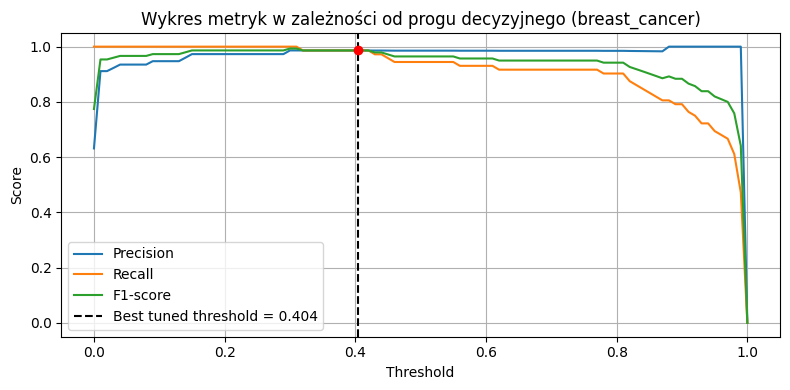

In [10]:
thresholds = np.linspace(0.0, 1.0, 101)
precision_vals, recall_vals, f1_vals = [], [], []

for t in thresholds:
    y_pred = (y_probs_base >= t).astype(int)
    precision_vals.append(precision_score(y_test, y_pred, zero_division=0))
    recall_vals.append(recall_score(y_test, y_pred))
    f1_vals.append(f1_score(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision_vals, label='Precision')
plt.plot(thresholds, recall_vals, label='Recall')
plt.plot(thresholds, f1_vals, label='F1-score')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Best tuned threshold = {best_threshold:.3f}')
plt.scatter([best_threshold], [f1_score(y_test, y_pred_tuned)], color='red', zorder=5)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Wykres metryk w zależności od progu decyzyjnego ({dataset})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Więcej:

* Post-tuning the decision threshold for cost-sensitive learning: https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html#sphx-glr-auto-examples-model-selection-plot-cost-sensitive-learning-py

* Tuning the decision threshold for class prediction: https://scikit-learn.org/stable/modules/classification_threshold.html 



# Krzywe uczenia (learning curve)

**Krzywa uczenia (ang. *learning curve*)** to narzędzie służące do oceny, jak zmienia się wydajność modelu uczenia maszynowego w zależności od liczby przykładów uczących. Pozwala na:

* wykrycie **niedouczenia** (underfittingu), gdy model osiąga niską dokładność nawet na zbiorze treningowym,
* wykrycie **przeuczenia** (overfittingu), gdy model ma wysoką dokładność na treningu, ale słabą na walidacji,
* ocenę, czy **zwiększenie liczby danych** przyniosłoby poprawę.

W scikit-learn funkcja `learning_curve` oblicza metryki dla rosnących rozmiarów zbioru treningowego. Do wizualizacji wyników służy `LearningCurveDisplay.from_estimator`.

---

Wykres:

* **Krzywa treningowa**: jak model uczy się na coraz większym zbiorze danych.
* **Krzywa walidacyjna**: jak rośnie jego ogólna zdolność do generalizacji.
* **Rozrzut** (pasy cieniowania): informacja o stabilności wyniku.

---

Parametry do optymalizacji: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

---

**Opis zbioru `digits` (scikit-learn)**

Zbiór `digits` to klasyczny, niewielki zbiór danych do klasyfikacji obrazów cyfr. Zawiera:

* **1797 próbek** obrazów cyfr (`0`–`9`)
* Każdy obraz to **8×8 pikseli** (czyli 64 cechy), wartości pikseli od `0` do `16`
* Celem jest **rozpoznanie cyfr** zapisanych odręcznie (klasyfikacja wieloklasowa)
Wymiary:

    * `X.shape = (1797, 64)`
    * `y.shape = (1797,)` (etykiety klas od 0 do 9)

---

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.model_selection import learning_curve
from sklearn.model_selection import LearningCurveDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [12]:
# Dane
X, y = load_digits(return_X_y=True)
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

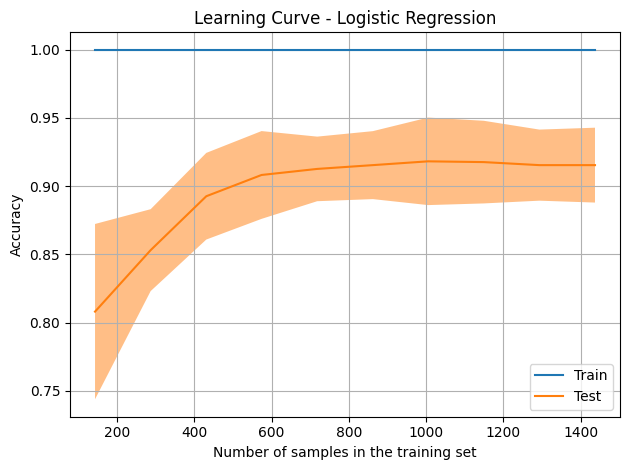

In [13]:
# Model: regresja logistyczna
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Krzywa uczenia
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

# Rysowanie krzywej
LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring='accuracy', # f1, precision, recall, ale trzeba wskazać właściwą klasę, można też np.: "precision_weighted"
    n_jobs=-1
)

plt.title("Learning Curve - Logistic Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretacja**:
  
* **Model**: Regresja logistyczna (`LogisticRegression`)
* **Dane**: Zbiór `digits` — rozpoznawanie cyfr (klasyfikacja wieloklasowa)
* **Metryka**: Dokładność klasyfikacji (`accuracy`)
* **Walidacja**: 5-krotna walidacja krzyżowa (`StratifiedKFold`)
* **Zakres danych uczących**: Od 10% do 100% zbioru

---

1. **Krzywa treningowa**:

   * Startuje wysoko (np. >0.99) przy małej liczbie próbek — model łatwo „zapamiętuje” dane.

2. **Krzywa walidacyjna**:

   * Zaczyna niżej (np. ok. 0.80) przy małej liczbie danych, ponieważ model generalizuje słabo przy ograniczonym treningu.
   * **Stopniowo rośnie**, pokazując, że model uczy się lepiej wraz ze wzrostem liczby przykładów uczących.
   * W końcu **osiąga plateau** — dalsze zwiększanie zbioru treningowego nie poprawia znacząco wyników.

---

**Wnioski**:

* **Brak silnego overfittingu**: odległość między krzywą treningową a walidacyjną nie jest drastyczna.
* **Model dobrze generalizuje**: walidacja osiąga wysoki poziom (np. >0.9), z niewielkim rozrzutem.
* **Zwiększanie danych może dać niewielką poprawę**, ale korzyści maleją — osiągnięto prawdopodobnie punkt nasycenia modelu.

---

Porównajmy różne modele:

In [14]:
# Modele
models = {
    'Regresja logistyczna': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'Drzewo decyzyjne': DecisionTreeClassifier(random_state=42),  # brak ograniczeń -> może być przeuczenie
    'Drzewo decyzyjne (głębokość = 1)': DecisionTreeClassifier(max_depth=1, random_state=42),  # bardzo prosty model, niedouczenie
    'Gaussian Naive Bayes': GaussianNB() # niedopasowanie założeń - niezależność cech
}

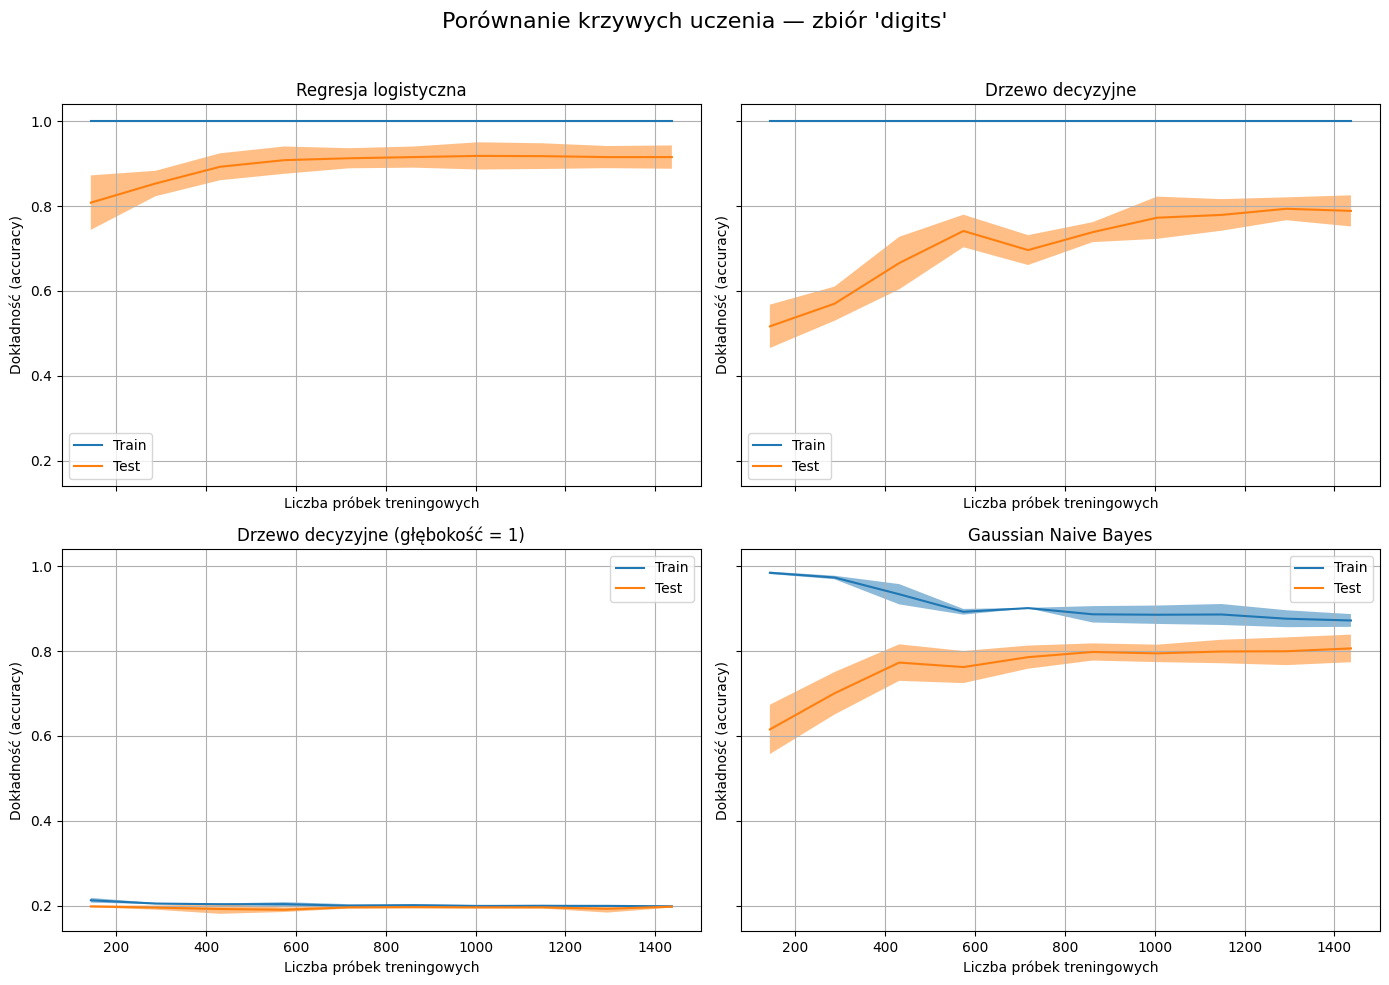

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.grid(True)

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

lub z wykorzystaniem: `learning_curv`:

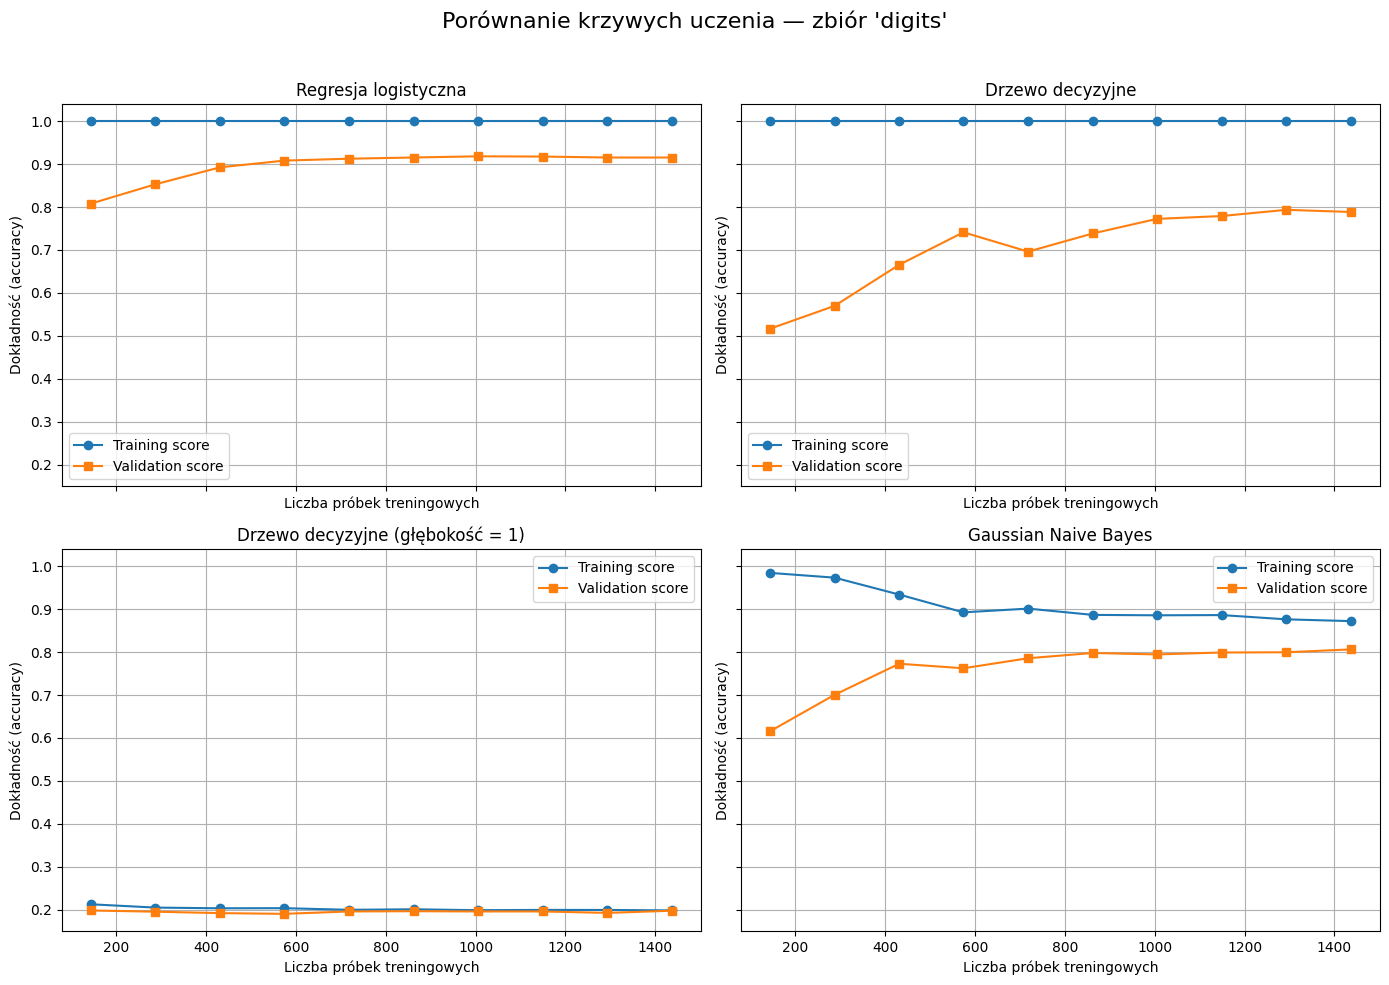

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes_abs, train_mean, label='Training score', marker='o')
    ax.plot(train_sizes_abs, val_mean, label='Validation score', marker='s')

    ax.set_title(name)
    ax.grid(True)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.legend()

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Interpretacja**:

* **Regresja logistyczna**: dobre dopasowanie, niewielka luka, dobra generalizacja.
* **Drzewo decyzyjne (bez ograniczeń)**: silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.
* **Drzewo głębokości 1**: underfitting — niska dokładność nawet na zbiorze treningowym.
* **GaussianNB**: umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.

Oto szczegółowe wyjaśnienie interpretacji wyników krzywych uczenia dla każdego z czterech modeli:

---

**1. Regresja logistyczna**

**Dobre dopasowanie, niewielka luka, dobra generalizacja.**

* **Krzywa treningowa i walidacyjna są blisko siebie**, co oznacza, że model nie przeucza się (brak dużej różnicy między wynikami na treningu a walidacji).
* **Obie krzywe osiągają wysoką dokładność (\~0.9 i więcej)**, co świadczy o tym, że model dobrze odwzorowuje zależności w danych.
* **Stabilny przebieg krzywej walidacyjnej** sugeruje, że model dobrze radzi sobie z generalizacją – potrafi trafnie klasyfikować dane, których wcześniej nie widział.

**Wniosek:** regresja logistyczna to prosty, ale skuteczny model liniowy, który działa dobrze, gdy dane mają strukturę nadającą się do separacji liniowej (jak w zbiorze `digits` po redukcji wymiarów).

---

**2. Drzewo decyzyjne (bez ograniczeń głębokości)**

**Silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.**

* **Trening accuracy ≈ 100%** — drzewo perfekcyjnie zapamiętuje dane treningowe (nawet szum).
* **Validation accuracy jest znacznie niższa i niestabilna** — model nie generalizuje dobrze, bo dostosował się zbyt dokładnie do konkretnych danych uczących.
* **Szeroka luka między krzywymi** wskazuje na przeuczenie (**overfitting**).

**Wniosek:** drzewo bez ograniczeń głębokości jest zbyt złożone. Dobrze "zapamiętuje" dane treningowe, ale nie uczy się ogólnych wzorców.

---

**3. Drzewo decyzyjne z maksymalną głębokością = 1**

**Underfitting — niska dokładność nawet na zbiorze treningowym.**

* **Trening accuracy jest niska (\~0.6–0.7)** — model jest zbyt prosty, by uchwycić nawet wzorce obecne w danych uczących.
* **Validation accuracy również niska i podobna do treningowej** — nie występuje overfitting, ale model też nie ma wystarczającej mocy predykcyjnej.
* **Brak poprawy wraz ze wzrostem danych** — model jest zbyt ograniczony.

**Wniosek:** zbyt mała głębokość drzewa powoduje **niedouczenie** (**underfitting**), nawet jeśli dostarczymy mu dużo danych.

---

**4. Gaussian Naive Bayes**

**Umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.**

* **Training accuracy umiarkowana (\~0.8), ale nie rośnie znacząco z liczbą danych** — model bazuje na uproszczonym założeniu niezależności cech.
* **Validation accuracy jest niższa, ale stabilna** — świadczy to o tym, że model generalizuje w sposób przewidywalny, ale ograniczony.
* **Brak dużej luki między krzywymi** nie oznacza, że model działa dobrze — tylko że **błędy wynikają z uproszczenia modelu**, a nie z nadmiernego dopasowania.

**Wniosek:** `GaussianNB` ma ograniczoną reprezentatywność dla złożonych zbiorów, takich jak obrazy cyfr, gdzie cechy są skorelowane (np. sąsiednie piksele).

---